In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
import os

# Load and preprocess the dataset
data_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..', '..', 'data', 'project2', 'diabetes.csv')
df = pd.read_csv(data_path)

In [ ]:
# --- Class Distribution ---
counts = df['Diabetes_binary'].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Diabetes (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Split')

plt.suptitle('Diabetes Dataset — Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# --- Feature Correlation with Target ---
correlations = df.drop(columns=['Diabetes_binary']).corrwith(df['Diabetes_binary']).sort_values()

colors = ['tomato' if c > 0 else 'steelblue' for c in correlations]

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Diabetes (Binary Target)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\nTop 5 positively correlated features:")
print(correlations.tail(5).to_string())
print("\nTop 5 negatively correlated features:")
print(correlations.head(5).to_string())

In [62]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [66]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [68]:
# 2L Neural Network (zero hidden layers)
class NN_2L(nn.Module):
    def __init__(self, input_dim):
        super(NN_2L, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

In [70]:
# 3L Neural Network (one hidden layer)
class NN_3L(nn.Module):
    def __init__(self, input_dim, hidden_dim=16):
        super(NN_3L, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.model(x)

In [72]:
# 4L Neural Network (two hidden layers)
class NN_4L(nn.Module):
    def __init__(self, input_dim, hidden1=32, hidden2=16):
        super(NN_4L, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.model(x)

In [74]:
# Picked architecture
class NN_5L(nn.Module):
    def __init__(self, input_dim, h1=64, h2=32, h3=16):
        super(NN_5L, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            
            nn.Linear(h1, h2),
            nn.ReLU(),
            
            nn.Linear(h2, h3),
            nn.ReLU(),
            
            nn.Linear(h3, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def train_model(model, train_loader, X_test_tensor, y_test_tensor, epochs=50, lr=0.01):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        epoch_correct = 0
        epoch_total = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            epoch_correct += (preds == yb).sum().item()
            epoch_total += yb.size(0)

        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(epoch_correct / epoch_total)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_test_tensor)
            val_loss = criterion(val_logits, y_test_tensor).item()
            val_preds = (torch.sigmoid(val_logits) > 0.5).float()
            val_acc = (val_preds == y_test_tensor).float().mean().item()

        val_losses.append(val_loss)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs

In [ ]:
def evaluate_model(model, X_data, y_data):
    model.eval()
    with torch.no_grad():
        logits = model(X_data)
        probs = torch.sigmoid(logits).numpy().flatten()
        preds = (probs > 0.5).astype(float)
        actual = y_data.numpy().flatten()

    acc = accuracy_score(actual, preds)
    f1 = f1_score(actual, preds, zero_division=0)
    fpr, tpr, _ = roc_curve(actual, probs)
    roc_auc = auc(fpr, tpr)

    return acc, f1, roc_auc, probs, actual

In [ ]:
def plot_training_curves(train_losses, val_losses, train_accs, val_accs, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(val_losses, label='Val Loss')
    axes[0].set_title(f'{model_name} — BCE Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(train_accs, label='Train Accuracy')
    axes[1].plot(val_accs, label='Val Accuracy')
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(actual, probs, model_name):
    preds = (probs > 0.5).astype(float)
    cm = confusion_matrix(actual, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(actual, probs, model_name):
    fpr, tpr, _ = roc_curve(actual, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
    plt.title(f'{model_name} — ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_precision_recall(actual, probs, model_name):
    precision, recall, _ = precision_recall_curve(actual, probs)
    ap = average_precision_score(actual, probs)
    baseline = actual.sum() / len(actual)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
    plt.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
    plt.title(f'{model_name} — Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_model(model_name, model):
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, X_test_tensor, y_test_tensor
    )

    train_acc, train_f1, train_auc, _, _ = evaluate_model(model, X_train_tensor, y_train_tensor)
    test_acc, test_f1, test_auc, test_probs, test_actual = evaluate_model(model, X_test_tensor, y_test_tensor)

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"{'Metric':<12} {'Train':>10} {'Test':>10}")
    print(f"{'-'*35}")
    print(f"{'Accuracy':<12} {train_acc:>10.4f} {test_acc:>10.4f}")
    print(f"{'F1 Score':<12} {train_f1:>10.4f} {test_f1:>10.4f}")
    print(f"{'AUC-ROC':<12} {train_auc:>10.4f} {test_auc:>10.4f}")

    plot_training_curves(train_losses, val_losses, train_accs, val_accs, model_name)
    plot_confusion_matrix(test_actual, test_probs, model_name)
    plot_roc_curve(test_actual, test_probs, model_name)
    plot_precision_recall(test_actual, test_probs, model_name)


2L Neural Network (zero hidden layers)
In-Sample:
MSE  = 0.1774
RMSE = 0.4211
R^2  = 0.2905
Validation:
MSE  = 0.1777
RMSE = 0.4215
R^2  = 0.2894


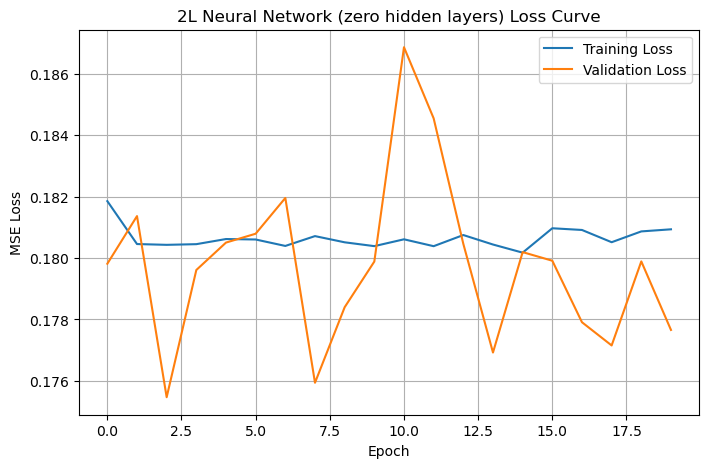


3L Neural Network (one hidden layer)
In-Sample:
MSE  = 0.1710
RMSE = 0.4135
R^2  = 0.3159
Validation:
MSE  = 0.1716
RMSE = 0.4142
R^2  = 0.3138


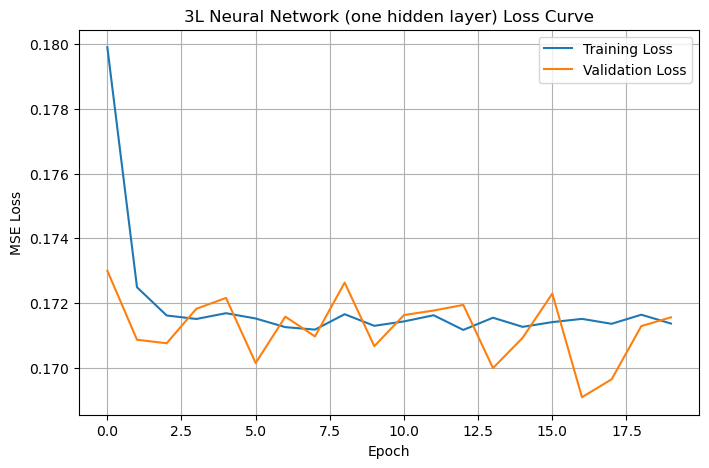


4L Neural Network (two hidden layers)
In-Sample:
MSE  = 0.1671
RMSE = 0.4088
R^2  = 0.3314
Validation:
MSE  = 0.1691
RMSE = 0.4112
R^2  = 0.3237


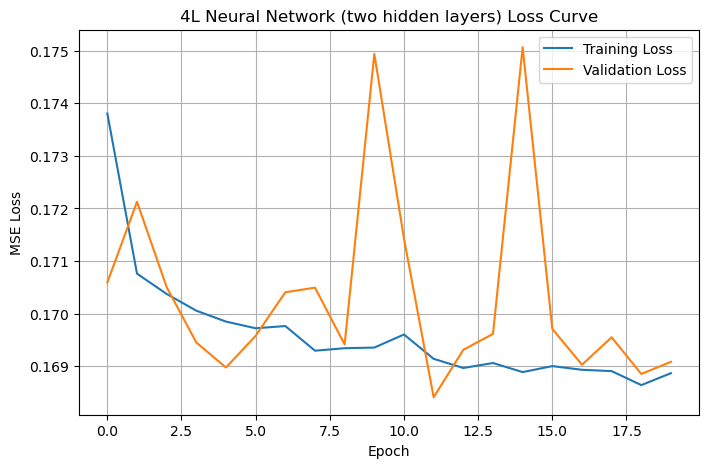


5L Neural Network (three hidden layers)
In-Sample:
MSE  = 0.1680
RMSE = 0.4099
R^2  = 0.3280
Validation:
MSE  = 0.1696
RMSE = 0.4118
R^2  = 0.3216


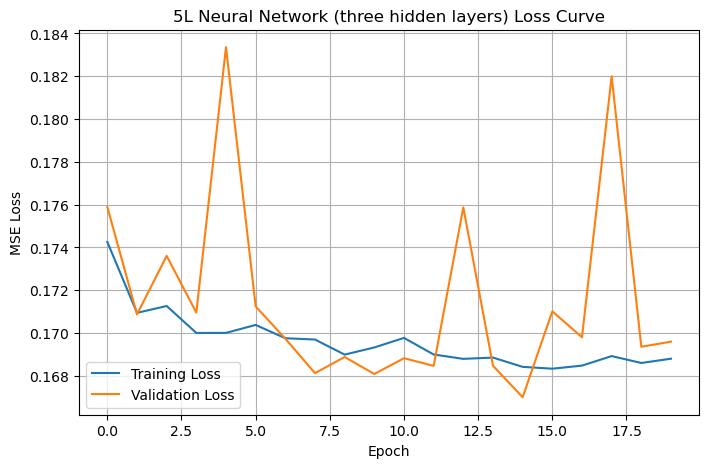

In [84]:
input_dim = X_train.shape[1]

model_2l = NN_2L(input_dim)
model_3l = NN_3L(input_dim, hidden_dim=16)
model_4l = NN_4L(input_dim, hidden1=32, hidden2=16)
model_5l = NN_5L(input_dim, h1=64, h2=32, h3=16)

run_model("2L Neural Network (zero hidden layers)", model_2l)
run_model("3L Neural Network (one hidden layer)", model_3l)
run_model("4L Neural Network (two hidden layers)", model_4l)
run_model("5L Neural Network (three hidden layers)", model_5l)